## Slowly-Quenched Bosonic Quantum Battery: Basic Formalism


### Interaction Picture Hamiltonian

We describe the energy transfer from resonant charger A to battery B as a nonequilibrium interaction driven by a time-dependent quench of duration $\tau_Q$. In this framework, the interaction is defined by the Hamiltonian:

$$
H(t)=g(t)\left(ab^\dagger+a^\dagger b\right)+F(a^\dagger+a),
$$

where $a,b$ $(a^\dagger,b^\dagger)$ represent the bosonic annihilation (creation) processes for charger and battery. We apply an external drive $F$ exclusively to the charger. The time-dependent coupling $g(t)$, characterized by a maximum strength $g_f$ and a positive real exponent $r$ (for $r < 1$, $r = 1$ (linear quench), and $r > 1$), describes a quench protocol:

$$
g(t) = 
    \begin{cases}
       {g_{f}} (t/\tau_Q)^r, & 0\leq t\leq \tau_Q,\\
       {g_{f}},              & t > \tau_Q.
    \end{cases}
$$

At the beginning $(t=0)$, both charger and battery are in the ground state $|\psi(0)\rangle_{AB}=|0\rangle_{A}|0\rangle_{B}$. Here, $|0\rangle_{A}$ and $|0\rangle_{B}$ denote the individual ground states with respect to the local Hamiltonians, $H_A = \omega_0 (a^\dagger a)$ and $H_B = \omega_0 (b^\dagger b)$. Notably, since the interaction term commutes with the free Hamiltonian, $[ab^\dagger + a^\dagger b, H_A + H_B] = 0$, the internal coupling does not exchange energy with the environment. Consequently, the external driving $F$ remains the sole source of energy injected into the charger.

### "Leaky" Cavity

In a perfectly isolated quantum system, energy is strictly conserved. This allows a battery and its charger to swap energy back and forth indefinitely, much like a frictionless pendulum in a vacuum. However, real-world systems are rarely isolated. In a realistic open quantum system, the charger sits within a leaky cavity, where it constantly interacts with the surrounding environment. These interactions lead to dissipation, causing energy to seep out and inevitably dampening the once-perfect exchange. To account for these environmental "leaks," the dynamics are usually described by the <strong>Gorini-Kossakowski-Sudarshan-Lindblad (GKSL) master equation</strong>:

\begin{align}
\dot{\rho}_{AB} = \mathcal L \rho_{AB} = \underbrace{-i[H(t),\rho_{AB}]}_{\text{Internal Dynamics}} + \underbrace{\gamma\mathcal D[a]\rho_{AB}.}_{\text{Environmental Leak}}
\tag{1} 
\end{align}

The term $\mathcal{D}[a]\rho$ acts as the dissipator, which mathematically models the "drain" on the system's energy or information at a rate $\gamma$. While the master equation typically tracks how the system's state ($\rho$) evolves (Schrödinger picture), it is often more efficient to track how the observable ($A$) evolves (Heisenberg picture). By utilizing the cyclicity of the trace ($\text{Tr}[AB] = \text{Tr}[BA]$), we can shift the time-evolution from the density matrix onto the operator itself:

$$\langle A(t)\rangle = \text{Tr}[A(0)e^{\mathcal{L}t}\rho(0)] = \text{Tr}[e^{\mathcal{L}^\dagger t}A(0)\rho(0)].$$

This identity allows us to ignore the full density matrix and focus solely on the adjoint equation:

$$\dot{A} = \mathcal{L}^\dagger A.$$

However, dealing with the full Liouvillian $\mathcal{L}$ in Eq. \ref{Liouvillian} is computationally expensive because it operates on density matrices. For certain problems, specifically quadratic problems where we don't care about "quantum jumps", we can replace the complex master equation with a simpler <strong>Non-Hermitian Hamiltonian</strong>: 

$$H_{NH}(t) = H(t) - i\frac{\gamma}{2} a^\dagger a.$$

To calculate the energy stored in battery and the average power over time $t$, we use 
\begin{align}
E_B(t)={\rm Tr}\left(H_B\:\rho(t)\right),
\tag{2} 
\end{align}
and
\begin{align}
P_B(t)=E_B(t)/t.
\tag{3} 
\end{align}

## Code: Energy and Power Evolution by solving Master Equation

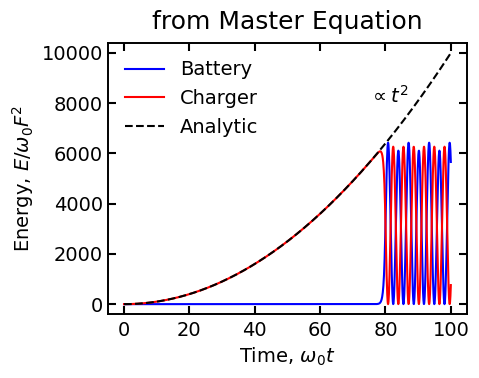

In [1]:
#------------------------------------------------------------------------#
#  Required Libraries:
#  -- NumPy for numerical operations,
#  -- Matplotlib for plotting, and
#  -- QuTiP for quantum system calculations
#------------------------------------------------------------------------#
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

#------------------------------------------------------------------------#
#  Physical and Model Parameters
#------------------------------------------------------------------------#
omega0 = 1.0    # Natural frequency of harmonic oscillator
F      = 0.01   # Strength of external driving applied to the charger
gamma  = 0.0    # Dissipation rate

tau_Q  = 80     # Quench duration
r      = 100    # Quench exponent
g_f    = 1.0    # Maximum strength of quenched coupling interation

#------------------------------------------------------------------------# 
#  Number of Fock states
#------------------------------------------------------------------------#
N = 20

#------------------------------------------------------------------------# 
#  Time-dependent Coupling Function, g(t)
#------------------------------------------------------------------------# 
def g(t, args=None):
    return g_f * (t/tau_Q)**r if t <= tau_Q else g_f

#------------------------------------------------------------------------#
#  Bosonic Annihilation Operators for Charger and Battery
#------------------------------------------------------------------------#
a = tensor(destroy(N), qeye(N))  # charger
b = tensor(qeye(N), destroy(N))  # battery

#------------------------------------------------------------------------#
#  Hamiltonian Components
#------------------------------------------------------------------------#
#  -- Isolated Hamiltonian (Harmonic Oscillator)
#------------------------------------------------------------------------#
H_charger = omega0 * a.dag() * a
H_battery = omega0 * b.dag() * b

#------------------------------------------------------------------------#
#  -- External Driving Applied only to the Charger
#------------------------------------------------------------------------#
H_drive = F * (a.dag() + a)

#------------------------------------------------------------------------#
#  -- Interaction Hamiltonian (Energy Exchange between Charger & Battery)
#------------------------------------------------------------------------#
H_inter = a * b.dag() + a.dag() * b

#------------------------------------------------------------------------#
#  Time-dependent Hamiltonian
#------------------------------------------------------------------------#
H = QobjEvo([H_drive, [H_inter, g]])

#------------------------------------------------------------------------#
#  Effective Hamiltonian
#------------------------------------------------------------------------#
H_eff = H - 1j * (gamma/2) * a.dag() * a

#------------------------------------------------------------------------#
#  Initial State
#------------------------------------------------------------------------#
psi0 = tensor(basis(N,0), basis(N,0))
rho0 = ket2dm(psi0)  # Convert to density matrix

#------------------------------------------------------------------------#
#  Time Evolution
#------------------------------------------------------------------------#
#  -- Time Grid for Simulation
#------------------------------------------------------------------------#
tlist = np.linspace(1e-6, 100, 1600)

#------------------------------------------------------------------------#
#  -- Solve Master Equation
#------------------------------------------------------------------------#
result = mesolve(H_eff, rho0, tlist, c_ops=[])
rhoAB  = result.states  # Density matrices at each time step

#------------------------------------------------------------------------#
#  State Normalization 
#------------------------------------------------------------------------#
norm = np.array([rho.tr() for rho in rhoAB])

#------------------------------------------------------------------------#
#  Energy Expectation Values 
#------------------------------------------------------------------------#
EA = np.array([expect(H_charger, rho) for rho in rhoAB]) / norm
EB = np.array([expect(H_battery, rho) for rho in rhoAB]) / norm

#------------------------------------------------------------------------#
#  Power (Time Derivative of Energy)
#------------------------------------------------------------------------#
PA = np.gradient(EA, tlist)
PB = np.gradient(EB, tlist)

#------------------------------------------------------------------------#
#  Analytic Reference Solution
#------------------------------------------------------------------------#
if gamma > 0:
    analytic = 4 * (np.exp(-gamma*tlist/2)-1)**2/gamma**2
else:
    analytic = tlist**2

#------------------------------------------------------------------------#
#  Plot Configuration and Visualization
#------------------------------------------------------------------------#
plt.figure(figsize=(5,4))

plt.rcParams['legend.frameon']    = False
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['xtick.major.size']  = '6'
plt.rcParams['xtick.major.width'] = '1.5'
plt.rcParams['xtick.minor.size']  = '3'
plt.rcParams['xtick.minor.width'] = '1'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['ytick.major.size']  = '6'
plt.rcParams['ytick.major.width'] = '1.5'
plt.rcParams['ytick.minor.size']  = '3'
plt.rcParams['ytick.minor.width'] = '1'
plt.rcParams['axes.linewidth']    = 1.4
plt.rcParams['axes.titlesize']    = '18'
plt.rcParams['axes.titlepad']     = '10'
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['mathtext.fontset']  = 'dejavusans'
plt.rcParams['xtick.major.pad']   = 5
plt.rcParams['font.size']         = 14

plt.plot(tlist, EB/(F**2), color='blue', label = 'Battery')
plt.plot(tlist, EA/(F**2), color='red',  label = 'Charger')
plt.plot(tlist, analytic,  'k--', label = 'Analytic')

plt.title('from Master Equation')
plt.ylim(-400,10400)
plt.text(75, 8000, r'$\propto t^2$')
plt.xlabel(r'Time, $\omega_0 t$')
plt.ylabel(r'Energy, $E/\omega_0 F^2$')
plt.legend()
plt.tight_layout()
plt.show()

## Phenomenological Description 

In Heisenberg picture, the equation of motion for operator $a$ is

\begin{align}
\langle\dot{a}\rangle & = -i[a,H_{NH}] \\
& = -i\left[a,g(t)\left(ab^\dagger+a^\dagger b\right)+F(a^\dagger+a)- i\frac{\gamma}{2} a^\dagger a\right] \\
& = -ig(t)[a,ab^\dagger]-ig(t)[a,a^\dagger b]-iF[a,a^\dagger]-iF[a,a]-\frac{\gamma}{2} [a,a^\dagger a] 
\end{align}

Using the commutation relations

$$
[a,bc]=[a,b]c, \quad [a,a]=0, \quad [a,b]=0, \quad [a,a^\dagger]=1, 
$$

we obtain

\begin{align*}
\langle\dot{a}\rangle & = -ig(t)\underbrace{[a, a]}_{0}b^\dagger - ig(t)\underbrace{[a, a^\dagger]}_{1}b - iF\underbrace{[a, a^\dagger]}_{1} - iF\underbrace{[a, a]}_{0} - \frac{\gamma}{2}\underbrace{[a, a^\dagger]}_{1}a \\
& = -ig(t)\langle{b}\rangle-iF-\frac{\gamma}{2}\langle{a}\rangle \\
& = -i\left(g(t)\langle{b}\rangle+F\right)-\frac{\gamma}{2}\langle{a}\rangle
\end{align*}

For operator $b$, we proceed similarly:

\begin{align*}
\langle\dot{b}\rangle & = -i[b,H_{NH}] \\
& = -i\left[b,g(t)\left(ab^\dagger+a^\dagger b\right)+F(a^\dagger+a)- i\frac{\gamma}{2} a^\dagger a\right] \\
& = -ig(t)[b,ab^\dagger]-ig(t)[b,a^\dagger b]-iF[b,a^\dagger]-iF[b,a]-\frac{\gamma}{2} [b,a^\dagger a] \\
& = -ig(t)a\underbrace{[b, b^\dagger]}_{1} - ig(t)a^\dagger\underbrace{[b,b]}_{0} - iF\underbrace{[b, a^\dagger]}_{0} - iF\underbrace{[b, a]}_{0} - \frac{\gamma}{2}\underbrace{[b, a^\dagger]}_{0}a \\
& = -ig(t)\langle{a}\rangle.
\end{align*}

For $t \leq \tau_Q$, the battery can be effectively decoupled from the charger. From the equation for $\langle\dot{b}\rangle$, we can rewrite

\begin{align*}
\langle{a}\rangle & = \frac{i}{g(t)}\langle\dot{b}\rangle.
\end{align*}

Defining $k=g_f/\tau_Q^r \rightarrow g_f=k\:\tau_Q^r$, now we have

\begin{align*}
\langle{a}\rangle & = \frac{i}{k\:t^r}\langle\dot{b}\rangle
\end{align*}

and

\begin{align*}
\langle{\dot{a}}\rangle & = \frac{d}{dt}\langle{a}\rangle = \frac{d}{dt} \frac{i}{k\:t^r}\langle\dot{b}\rangle \\
& = \frac{i}{k}\left(-r\:t^{-r-1}\langle\dot{b}\rangle+t^{-1}\langle\ddot{b}\rangle\right)
\end{align*}

Rearranging all above equations, we find

\begin{align*}
\frac{i}{k}\left(-r\:t^{-r-1}\langle\dot{b}\rangle+t^{-1}\langle\ddot{b}\rangle\right) & = -i(k\:t^r) \langle{b}\rangle -iF - \frac{\gamma i}{2k} t^{-r} \langle\dot{b}\rangle \\
\end{align*}

Multiply both sides by $-ikt^r$ yields

\begin{align}
-\frac{r}{t}\langle\dot{b}\rangle + \langle\ddot{b}\rangle & = -k^2\:t^{2r} \langle{b}\rangle - k\:t^2F - \frac{\gamma}{2}\langle\dot{b}\rangle \nonumber\\
t\langle\ddot{b}\rangle + \left({\frac{\gamma t}{2}-r}\right) \langle\dot{b}\rangle + k^2t^{2r+1}\langle{b}\rangle &= -k\:t^{r+1}F.
\tag{4}
\end{align}

## Dissipationless Charger

For a closed system, $\gamma=0$, Eq. (4) becomes

\begin{align}
t\langle\ddot{b}\rangle -r \langle\dot{b}\rangle + k^2t^{2r+1}\langle{b}\rangle &= -k\:t^{r+1}F,
\end{align}

which is a linear nonhomogeneous Emden-Fowler equation. The homogeneous solution is proportional to $\exp \left(\pm \frac{\theta (t)}{1+r}\right)$, where $\theta(t)=kt^{1+r}$.



## Code: Energy and Power Evolution (Phenomenological)

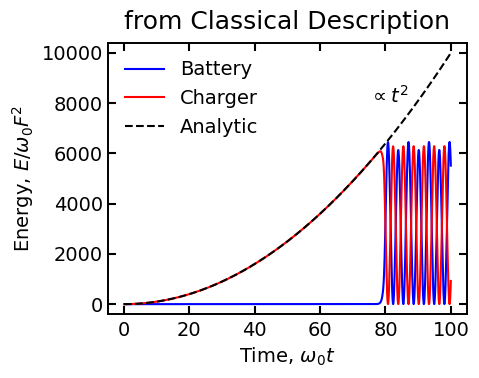

In [7]:
#------------------------------------------------------------------------#
#  Required Libraries
#------------------------------------------------------------------------#
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#------------------------------------------------------------------------#
#  Physical and Model Parameters
#------------------------------------------------------------------------#
omega0 = 1.0
F      = 0.01
gamma  = 0.0

tau_Q  = 80
r      = 100
g_f    = 1.0

#------------------------------------------------------------------------#
#  Equations of motion
#------------------------------------------------------------------------#
def QB(t, z, params):
    g     = params["g"]
    tau   = params["tau"]
    r     = params["r"]
    F     = params["F"]
    gamma = params["gamma"]

    G = g * (t / tau) ** r if t <= tau else g

    x1, p1, x2, p2 = z

    dx1 =  G * p2 - 0.5 * gamma * x1
    dp1 = -G * x2 - np.sqrt(2) * F - 0.5 * gamma * p1
    dx2 =  G * p1
    dp2 = -G * x1

    return [dx1, dp1, dx2, dp2]

#------------------------------------------------------------------------#
#  Time grid
#------------------------------------------------------------------------#
t = np.linspace(1e-6, 100, 1600)

params = {
    'g'    : g_f,
    'tau'  : tau_Q,
    'F'    : F,
    'gamma': gamma,
    'r'    : r
}

#------------------------------------------------------------------------#
#  Solve ODE
#------------------------------------------------------------------------#
sol = solve_ivp(
    QB,
    (t[0], t[-1]),
    [0, 0, 0, 0],
    t_eval=t,
    args=(params,),
)

z = sol.y
x1, p1, x2, p2 = z

#------------------------------------------------------------------------#
#  Energy
#------------------------------------------------------------------------#
EA = omega0 * (x1**2 + p1**2) / 2
EB = omega0 * (x2**2 + p2**2) / 2

#------------------------------------------------------------------------#
#  Power (better definition)
#------------------------------------------------------------------------#
PA = EA/t
PB = EB/t

#------------------------------------------------------------------------#
#  Plot Configuration and Visualization
#------------------------------------------------------------------------#
plt.figure(figsize=(5,4))

plt.rcParams['legend.frameon']    = False
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['xtick.major.size']  = '6'
plt.rcParams['xtick.major.width'] = '1.5'
plt.rcParams['xtick.minor.size']  = '3'
plt.rcParams['xtick.minor.width'] = '1'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['ytick.major.size']  = '6'
plt.rcParams['ytick.major.width'] = '1.5'
plt.rcParams['ytick.minor.size']  = '3'
plt.rcParams['ytick.minor.width'] = '1'
plt.rcParams['axes.linewidth']    = 1.4
plt.rcParams['axes.titlesize']    = '18'
plt.rcParams['axes.titlepad']     = '10'
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['mathtext.fontset']  = 'dejavusans'
plt.rcParams['xtick.major.pad']   = 5
plt.rcParams['font.size']         = 14

plt.plot(tlist, EB/(F**2), color='blue', label = 'Battery')
plt.plot(tlist, EA/(F**2), color='red',  label = 'Charger')
plt.plot(tlist, analytic,  'k--', label = 'Analytic')

plt.title('from Classical Description')
plt.ylim(-400,10400)
plt.text(75, 8000, r'$\propto t^2$')
plt.xlabel(r'Time, $\omega_0 t$')
plt.ylabel(r'Energy, $E/\omega_0 F^2$')
plt.legend()
plt.tight_layout()
plt.show()

## Figures for Paper

### Fig. 2. Temporal extensivity of the charging process in a lossless system ($\gamma=0$) with a linear quench profile ($r=1$).

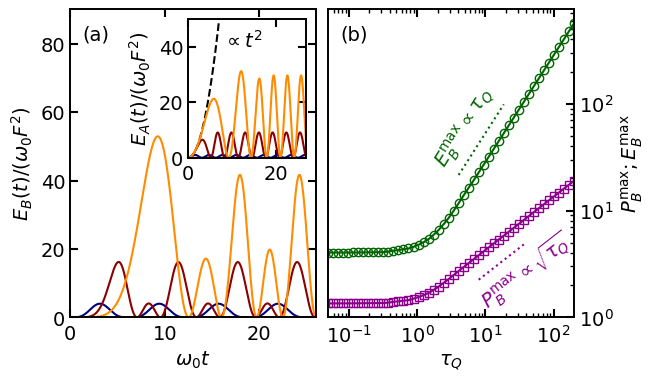

In [66]:
#------------------------------------------------------------------------#
#  Required Libraries
#------------------------------------------------------------------------#
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#------------------------------------------------------------------------#
#  Physical and Model Parameters
#------------------------------------------------------------------------#
omega0 = 1.0
F      = 0.01

gamma_list = [0.0, 0.1, 1.0, 10.0]
tau_list   = np.logspace(-1.3,2.3,50)

r      = 1.0
g_f    = 1.0

#------------------------------------------------------------------------#
#  Equations of motion
#------------------------------------------------------------------------#
def QB(t, z, params):
    g     = params["g"]
    tau   = params["tau"]
    r     = params["r"]
    F     = params["F"]
    gamma = params["gamma"]

    G = g * (t / tau) ** r if t <= tau else g

    x1, p1, x2, p2 = z

    dx1 =  G * p2 - 0.5 * gamma * x1
    dp1 = -G * x2 - np.sqrt(2) * F - 0.5 * gamma * p1
    dx2 =  G * p1
    dp2 = -G * x1

    return [dx1, dp1, dx2, dp2]

#------------------------------------------------------------------------#
#  Time grid
#------------------------------------------------------------------------#
t = np.linspace(1e-6, 200, 10000)

#------------------------------------------------------------------------#
#  Energy and Power Evolution
#------------------------------------------------------------------------#

E_A = []; E_B = []; P_A = []; P_B = []

for gamma in gamma_list:
    for tau_Q in tau_list:
        params = {'g'    : g_f, 
                  'tau'  : tau_Q,
                  'F'    : F,
                  'gamma': gamma,
                  'r'    : r}
        
        sol = solve_ivp(
                        QB,
                        (0, t[-1]),
                        [0, 0, 0, 0],
                        t_eval=t,
                        args=(params,),
                        dense_output=True
                        )
        z = sol.y
        x1, p1, x2, p2 = z

        EA = omega0 * (x1**2 + p1**2) / 2; E_A.append(EA)
        EB = omega0 * (x2**2 + p2**2) / 2; E_B.append(EB)

        PA = EA/t; P_A.append(PA)
        PB = EB/t; P_B.append(PB)

E_A = np.array(E_A).reshape([len(gamma_list),len(tau_list),len(t)])
E_B = np.array(E_B).reshape([len(gamma_list),len(tau_list),len(t)])
P_A = np.array(P_A).reshape([len(gamma_list),len(tau_list),len(t)])
P_B = np.array(P_B).reshape([len(gamma_list),len(tau_list),len(t)]) 

E_A_tau = [[max(E_A[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
E_B_tau = [[max(E_B[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
P_A_tau = [[max(P_A[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
P_B_tau = [[max(P_B[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]

#------------------------------------------------------------------------#
#  Plot Configuration and Visualization
#------------------------------------------------------------------------#

plt.rcParams['legend.frameon']    = False
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['xtick.major.size']  = '6'
plt.rcParams['xtick.major.width'] = '1.5'
plt.rcParams['xtick.minor.size']  = '3'
plt.rcParams['xtick.minor.width'] = '1'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['ytick.major.size']  = '6'
plt.rcParams['ytick.major.width'] = '1.5'
plt.rcParams['ytick.minor.size']  = '3'
plt.rcParams['ytick.minor.width'] = '1'
plt.rcParams['axes.linewidth']    = 1.4
plt.rcParams['axes.titlesize']    = '18'
plt.rcParams['axes.titlepad']     = '10'
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['mathtext.fontset']  = 'dejavusans'
plt.rcParams['xtick.major.pad']   = 5
plt.rcParams['font.size']         = 14

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6.5,4.0))

tau_plot = [0, 28, 35]
colors   = ['navy', 'darkred', 'darkorange']

#------------------------------------------------------------------------#
#  Panel (a)
#------------------------------------------------------------------------#

ax1.set_ylim(0,90)
ax1.set_xlim(0,26)
ax1.set_ylabel(r'$E_B(t)/(\omega_0F^2)$')
ax1.set_xlabel(r'$\omega_0 t$')

ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, va='top', ha='left')

#------------------------------------------------------------------------#
#  Inset Panel (a)
#------------------------------------------------------------------------#
    
ax1i = inset_axes(ax1, w="48%", h="45%", loc='upper right', borderpad=0.5)
ax1i.set_ylim(0,50)
ax1i.set_xlim(0,27)
ax1i.set_ylabel(r'$E_A(t)/(\omega_0F^2)$')

ax1i.plot(t, t**2, ls='--', color='black')
ax1i.text(8,40, r'$\propto t^2$')

for tau_, color_ in zip(tau_plot, colors):
    ax1.plot(t,  E_B[0,tau_]/(F**2), color=color_)
    ax1i.plot(t, E_A[0,tau_]/(F**2), color=color_)

#------------------------------------------------------------------------#
#  Panel (b)
#------------------------------------------------------------------------#

r = 1; alpha = r/(r+1)

ax2.plot(tau_list,np.array(E_B_tau[0])/F**2, marker='o', 
         mfc='None', ms=6, color='darkgreen')
ax2.plot(tau_list,np.array(P_B_tau[0])/F**2, marker='s', 
         mfc='None', ms=6, color='darkmagenta')

ax2.plot(tau_list[30:40],10**-0.1*tau_list[30:40]**alpha,     
         ls=':', color='darkmagenta')
ax2.plot(tau_list[26:36],  8**0.8*tau_list[26:36]**(2*alpha), 
         ls=':', color='darkgreen')

ax2.text(5, 60,   r'$E_B^{\max}\propto \tau_Q$',        
         color='darkgreen',   rotation=58, va='center', ha='center')
ax2.text(40, 2.7, r'$P_B^{\max}\propto \sqrt{\tau_Q}$', 
         color='darkmagenta', rotation=38, va='center', ha='center')

ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlim(10**-1.3,10**2.3)
ax2.set_xlabel(r'$\tau_Q$') 
ax2.set_ylabel(r'$P_B^{\max};E_B^{\max}$')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.tick_params(axis='y', labelleft=False, labelright=True)

ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, va='top', ha='left')

plt.subplots_adjust(wspace=0.05)
plt.savefig('fig2.pdf', dpi=600, format='pdf', bbox_inches='tight')
plt.show()


### Fig. 3. Effect of charger dissipation $\gamma$ on the battery performance.

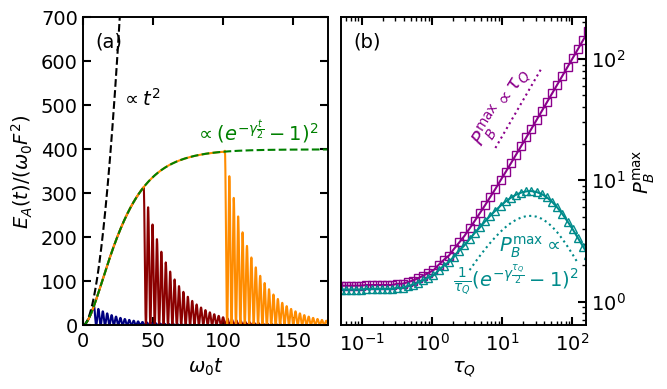

In [97]:
#------------------------------------------------------------------------#
#  Required Libraries
#------------------------------------------------------------------------#
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#------------------------------------------------------------------------#
#  Physical and Model Parameters
#------------------------------------------------------------------------#
omega0 = 1.0
F      = 0.01

gamma_list = [0.0, 0.1, 1.0, 10.0]
tau_list   = np.logspace(-1.3,2.3,50)

r      = 1000
g_f    = 1.0

#------------------------------------------------------------------------#
#  Equations of motion
#------------------------------------------------------------------------#
def QB(t, z, params):
    g     = params["g"]
    tau   = params["tau"]
    r     = params["r"]
    F     = params["F"]
    gamma = params["gamma"]

    G = g * (t / tau) ** r if t <= tau else g

    x1, p1, x2, p2 = z

    dx1 =  G * p2 - 0.5 * gamma * x1
    dp1 = -G * x2 - np.sqrt(2) * F - 0.5 * gamma * p1
    dx2 =  G * p1
    dp2 = -G * x1

    return [dx1, dp1, dx2, dp2]

#------------------------------------------------------------------------#
#  Time grid
#------------------------------------------------------------------------#
t = np.linspace(1e-6, 200, 10000)

#------------------------------------------------------------------------#
#  Energy and Power Evolution
#------------------------------------------------------------------------#

E_A = []; E_B = []; P_A = []; P_B = []

for gamma in gamma_list:
    for tau_Q in tau_list:
        params = {'g'    : g_f, 
                  'tau'  : tau_Q,
                  'F'    : F,
                  'gamma': gamma,
                  'r'    : r}
        
        sol = solve_ivp(
                        QB,
                        (0, t[-1]),
                        [0, 0, 0, 0],
                        t_eval=t,
                        args=(params,),
                        dense_output=True
                        )
        z = sol.y
        x1, p1, x2, p2 = z

        EA = omega0 * (x1**2 + p1**2) / 2; E_A.append(EA)
        EB = omega0 * (x2**2 + p2**2) / 2; E_B.append(EB)

        PA = EA/t; P_A.append(PA)
        PB = EB/t; P_B.append(PB)

E_A = np.array(E_A).reshape([len(gamma_list),len(tau_list),len(t)])
E_B = np.array(E_B).reshape([len(gamma_list),len(tau_list),len(t)])
P_A = np.array(P_A).reshape([len(gamma_list),len(tau_list),len(t)])
P_B = np.array(P_B).reshape([len(gamma_list),len(tau_list),len(t)]) 

E_A_tau = [[max(E_A[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
E_B_tau = [[max(E_B[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
P_A_tau = [[max(P_A[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]
P_B_tau = [[max(P_B[k,i]) for i in range(len(tau_list))] 
                          for k in range(len(gamma_list))]

#------------------------------------------------------------------------#
#  Plot Configuration and Visualization
#------------------------------------------------------------------------#

plt.rcParams['legend.frameon']    = False
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['xtick.major.size']  = '6'
plt.rcParams['xtick.major.width'] = '1.5'
plt.rcParams['xtick.minor.size']  = '3'
plt.rcParams['xtick.minor.width'] = '1'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['ytick.major.size']  = '6'
plt.rcParams['ytick.major.width'] = '1.5'
plt.rcParams['ytick.minor.size']  = '3'
plt.rcParams['ytick.minor.width'] = '1'
plt.rcParams['axes.linewidth']    = 1.4
plt.rcParams['axes.titlesize']    = '18'
plt.rcParams['axes.titlepad']     = '10'
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['mathtext.fontset']  = 'dejavusans'
plt.rcParams['xtick.major.pad']   = 5
plt.rcParams['font.size']         = 14

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6.5,4))

id_gamma = 1 # gamma index
tau_plot = [30, 40, 45]
colors   = ['navy', 'darkred', 'darkorange']

#------------------------------------------------------------------------#
#  Panel (a)
#------------------------------------------------------------------------#
ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, va='top', ha='left')

ax1.set_ylim(0,700)
ax1.set_xlim(0,175)
ax1.set_ylabel(r'$E_A(t)/(\omega_0F^2)$')
ax1.set_xlabel(r'$\omega_0 t$')

for tau_, color_ in zip(tau_plot, colors):
    ax1.plot(t, E_A[id_gamma,tau_]/F**2, color=color_)

ax1.plot(t, t**2, ls='--', color='black')
ax1.text(27,500, r'$\propto t^2$')

ax1.plot(t, 4.0/gamma_list[id_gamma]**2 * (np.exp(-gamma_list[id_gamma]*t/2)-1)**2, 
         ls='--', color='green')
ax1.text(80,420, r'$\propto (e^{-\gamma \frac{t}{2}}-1)^2$', color='green')

#------------------------------------------------------------------------#
#  Panel (b)
#------------------------------------------------------------------------#
ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, va='top', ha='left')

ax2.plot(tau_list,np.array(P_B_tau[0])/F**2,
         marker='s', mfc='None', ms=6, color='darkmagenta')
ax2.plot(tau_list,np.array(P_B_tau[1])/F**2, 
         marker='^', mfc='None', ms=6, color='darkcyan')

ax2.plot(tau_list[30:40],2.3*tau_list[30:40]**exp, ls=':', color='darkmagenta')
ax2.plot(tau_list[25:47], 2.5/(tau_list[25:47]*gamma_list[1]**2) * 
         (np.exp(-gamma_list[1]*tau_list[25:47]/2)-1)**2,ls=':',color='darkcyan')

ax2.text(10, 40,  r'$P_B^{\max}\propto \tau_Q$',        
         color='darkmagenta',   rotation=58, va='center', ha='center')
ax2.text(9,2.8, r'$P_B^{\max}\propto$', 
         color='darkcyan', va='center', ha='left')
ax2.text(2, 1.5, r'$\frac{1}{\tau_Q}(e^{-\gamma \frac{\tau_Q}{2}}-1)^2$', 
         color='darkcyan', va='center', ha='left')

ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlim(10**-1.3,10**2.2)
ax2.set_xlabel(r'$\tau_Q$') 
ax2.set_ylabel(r'$P_B^{\max}$')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.tick_params(axis='y', labelleft=False, labelright=True)

plt.subplots_adjust(wspace=0.05)
plt.savefig('fig3.pdf', dpi=600, format='pdf', bbox_inches='tight')
plt.show()